# Imports/Settings

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# 1. Стандартная библиотека
import os
import sys
import warnings
from pathlib import Path

# --- ДИНАМИЧЕСКИЙ РАСЧЕТ АБСОЛЮТНЫХ ПУТЕЙ ---
notebook_dir = Path(os.getcwd()).resolve()
if notebook_dir.name == "notebooks":
    PROJECT_ROOT = notebook_dir.parent
else:
    PROJECT_ROOT = notebook_dir

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 2. Сторонние библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Локальные модули (Движок)
from src.core.data import UniversalDataLoader
from src.core.pipeline import MLPipeline
from src.core.utils import load_hydra_config
from src.core.artifacts import ArtifactManager
from src.eda.visualisation import feature_importance


# --- РАБОТА С ПРЕДУПРЕЖДЕНИЯМИ ---
warnings.filterwarnings('ignore', category=FutureWarning)

# --- ИНИЦИАЛИЗАЦИЯ HYDRA ---
load_hydra_config.cache_clear()
cfg = load_hydra_config()


print(f"Проект: {cfg.project_name} | Режим: Baseline Modeling")

try:
    p_cfg = cfg.logging.plots
    plt.style.use(p_cfg.style)
    plt.rcParams.update({
        'figure.figsize': p_cfg.fig_size,
        'figure.dpi': p_cfg.dpi,
        'font.size': p_cfg.font_size,
        'axes.grid': p_cfg.grid,
        'axes.spines.top': p_cfg.spines_top,
        'axes.spines.right': p_cfg.spines_right
    })
    PLOT_ALPHA = p_cfg.alpha
except AttributeError:
    PLOT_ALPHA = 0.5
    print("Используются дефолтные стили Matplotlib.")

Проект: outsource_project_name | Режим: Baseline Modeling


# Data Loading

In [3]:
loader = UniversalDataLoader(cfg)
df = loader.load_data()

# Наш метод get_splits сам разобьет данные согласно config.data.test_size
train_df, val_df, test_df = loader.get_splits(df)

target = cfg.data.tabular.target_col

X_train, y_train = train_df.drop(columns=[target]), train_df[target]
X_val, y_val = val_df.drop(columns=[target]), val_df[target]
X_test, y_test = test_df.drop(columns=[target]), test_df[target]

print(f"Обучающая выборка: {X_train.shape}")
print(f"Валидационная выборка: {X_val.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (65352, 19)
Валидационная выборка: (9336, 19)
Тестовая выборка: (18673, 19)


# Baselinge

In [4]:
# 1. Инициализируем наш ООП-менеджер артефактов
tracker = ArtifactManager(cfg)

# 2. Достаем имя эксперимента для режима train
mode_for_exp = cfg.mode.lower() if cfg.mode else "train"
experiment_name = cfg.logging.mlflow.experiments.get(mode_for_exp, "default_experiment")

tracker.set_experiment(experiment_name, artifact_location=tracker.artifact_uri)

# 4. Берем динамический run_name прямо из конфига Hydra
run_name = cfg.run_name

In [8]:
# 5. Открываем сессию через контекстный менеджер нашего трекера
with tracker.start_run(run_name=cfg.run_name):
    print(f"Запуск MLflow Run: {cfg.run_name}")
    
    pipeline = MLPipeline(cfg)
    model = pipeline.train(X_train, y_train, X_val, y_val, save_artifacts=True)
    
    print("Обучение завершено! База данных и артефакты успешно инициализированы.")

Запуск MLflow Run: p_v1.0.0__f_v1.0.0__m_v0.1.0
0:	learn: 0.6894051	test: 0.6900792	best: 0.6900792 (0)	total: 134ms	remaining: 2m 14s
50:	learn: 0.6375323	test: 0.6520064	best: 0.6520064 (50)	total: 3.44s	remaining: 1m 3s
100:	learn: 0.6269885	test: 0.6473482	best: 0.6473482 (100)	total: 8.67s	remaining: 1m 17s
150:	learn: 0.6193224	test: 0.6438240	best: 0.6438240 (150)	total: 13.7s	remaining: 1m 17s
200:	learn: 0.6133131	test: 0.6414928	best: 0.6414928 (200)	total: 18.7s	remaining: 1m 14s
250:	learn: 0.6009908	test: 0.6380635	best: 0.6380106 (247)	total: 27.7s	remaining: 1m 22s
300:	learn: 0.5839643	test: 0.6368988	best: 0.6365681 (287)	total: 33.2s	remaining: 1m 16s
350:	learn: 0.5696779	test: 0.6356141	best: 0.6350397 (329)	total: 37.3s	remaining: 1m 8s
400:	learn: 0.5567868	test: 0.6376657	best: 0.6350397 (329)	total: 41.8s	remaining: 1m 2s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6350396521
bestIteration = 329

Shrink model to first 330 iterations.
   

c:\sber_autopodpiska\.venv\lib\site-packages\omegaconf\grammar_visitor.py:253: UserWarning: In the sequence `API_ALLOWED_KEYS,` some elements are missing: please replace them with empty quoted strings. See https://github.com/omry/omegaconf/issues/572 for details.
  warnings.warn(


# Feature Importance

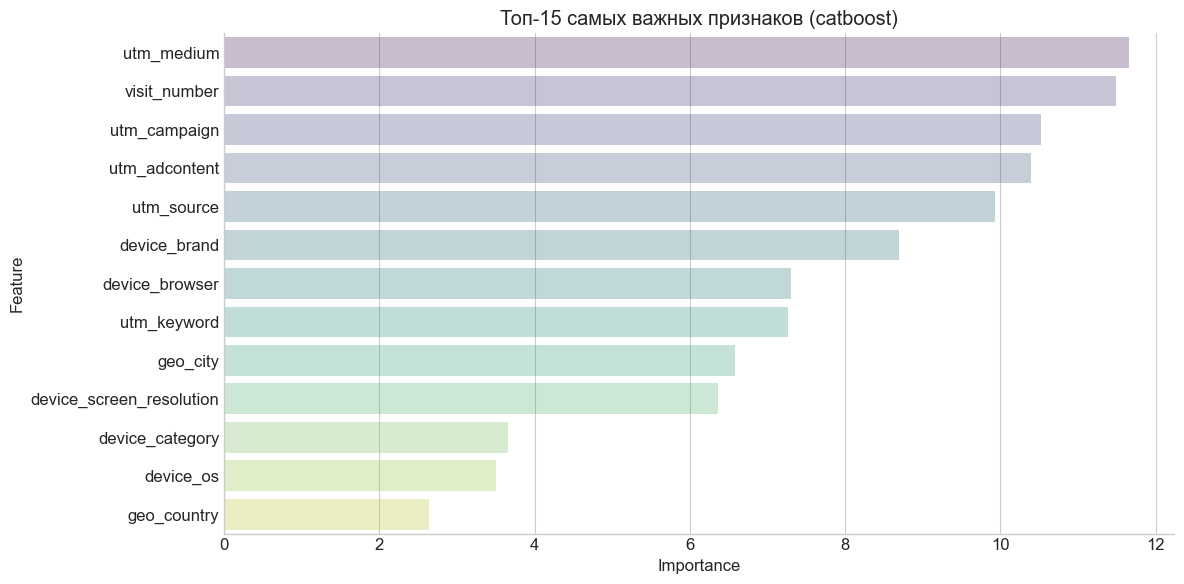

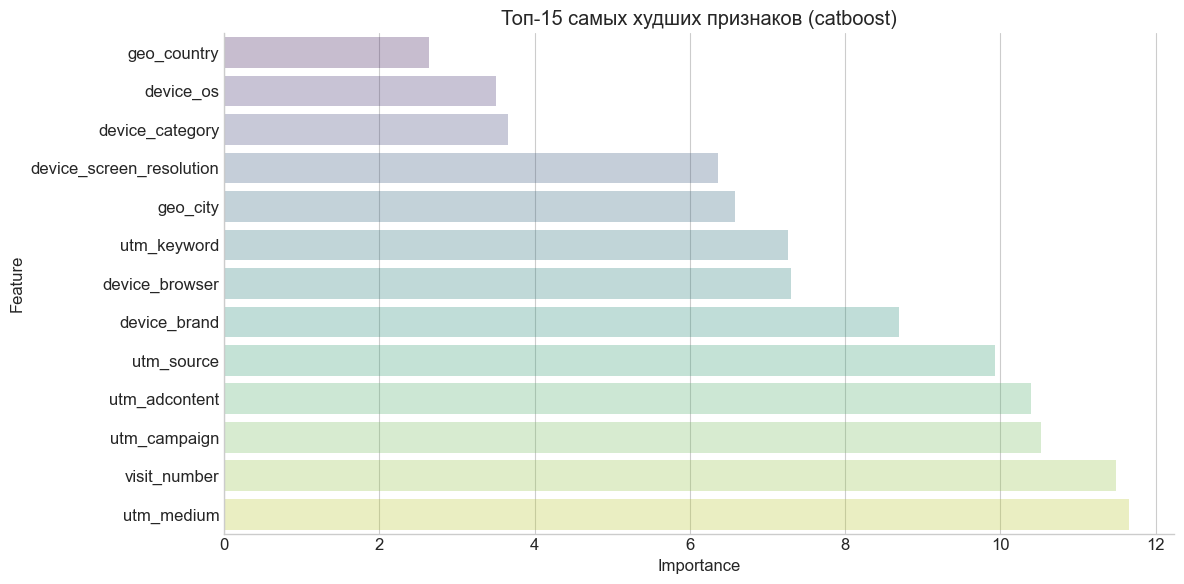

In [18]:
if hasattr(model.model, 'feature_importances_'):
    importances = model.model.feature_importances_
    
    # 1. Просто прогоняем тестовые признаки через предобработку
    X_test_clean = pipeline.preprocessor.transform(X_test)
    
    # 2. Имена колонок гарантированно лежат в самом чистом DataFrame!
    feature_names = X_test_clean.columns.tolist()

    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    feature_importance(fi_df=fi_df)
else:
    print("У выбранной модели нет встроенного атрибута feature_importances_.")

# Выводы по Feature Importance

- unique_event_actions - Огромный отрыв, логично что количество уникальных типов действий отражает глубину исследования сервиса. Пользватель который исопльзует много разных инструментов имеет другой паттерн поведения
- car_view_ratio и total_car_views -если пользователь сосредоточен на машинах а не ползает по всему сайту то конверсия возрастает
- visit_number прогрев клиента, чем больше раз заходил тем выше конверсия
- screen_area - возможно влияет адаптированность интерфейса под экран 

# Выводы по худшим фичам

- geo_country вероятно потому что большая часть всех запросов из России, поэтому этот параметр одинаково влияет как на таргет так и на пустые действия
- geo_zone как производная от geo_country
- is_weekend неожиданно но день недели не влияет на конверсию
- is_first_hit_car_view еще более неожиданно но то откуда пришел клиент по машине или на другую страницу также не сильно влияет на конверсию